In [9]:
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os
import re

import importlib
import cleaning as clean

---
New notebook post data cleaning.

In [3]:
data_path = os.path.abspath("../data/tcga_data2.csv")
raw_df = pd.read_csv(data_path, sep = '\t', low_memory = False)
raw_df.head(1)

,Gene,Study of Origin,Sample ID,Cancer Type,Cancer Type Detailed,Protein Change,Annotation,Custom Driver,Custom Driver Tiers,Functional Impact,...,Tumor Type,Used in Genomic Analysis,Vascular invasion indicator,Vessel Invasion,Vial number,Patient's Vital Status,Patient Weight,WGD,Winter Hypoxia Score,Year of Diagnosis
0,APC,"Colorectal Adenocarcinoma (TCGA, Firehose Legacy)",TCGA-AA-A010-01,Colorectal Cancer,Colon Adenocarcinoma,A2D,"OncoKB: Unknown, level NA, resistance NA;reVUE...",NaN,NaN,MutationAssessor: NA;SIFT: impact: deleterious...,...,NaN,NaN,NO,NaN,A,NaN,NaN,NaN,NaN,NaN


In [5]:
relevant = ["Gene", "Sample ID", "Cancer Type Detailed", "Mutation Type", "Variant Type", "HGVSc", "MS", 
        "Protein Change", "Functional Impact"]
clean_df = clean.clean_data(raw_df,
                relevant_cols = relevant, early_age = 50)
clean_df.head(1)

,Gene,Sample ID,Cancer Type Detailed,Mutation Type,Variant Type,HGVSc,MS,Protein Change,Functional Impact,Age,Early Onset
0,APC,TCGA-AA-A010-01,Colon Adenocarcinoma,Missense_Mutation,SNP,ENST00000257430.4:c.5C>A,Somatic,A2D,MutationAssessor: NA;SIFT: impact: deleterious...,46.0,True


---
---
---

All signature information is `GRCh38`.

In [78]:
# Note that the Context labels are not in the same order as in the Webpage.
data_path_signatures = os.path.abspath("../data/Context_SBS_2.txt")
sig_df = pd.read_csv(data_path_signatures, sep = ",")

sig_df.head(1)

,Context,SBS88_GRCh38,SBS1_GRCh38,SBS5_GRCh38,SBS18_GRCh38
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534


Liang/Adele's notebook does the following cleaning/prep on the signatures.
1. Add a `Normal_colon` signature profile as $0.4*SBS1 + 0.4*SBS5 + 0.2*SBS18$.
1. Reorder the data so that the basis change is first (match the web graphics).

Put those together in `cleaning.py`'s `clean_sigs()`. Added a `Mutation` column just for colouring the bar charts (below).

In [88]:
importlib.reload(clean)
clean_sig_df = clean.clean_sigs(sig_df)
clean_sig_df.head(1)

,Context,SBS88,SBS1,SBS5,SBS18,Normal,Mutation
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534,0.015456,C>A


In [ ]:
def threshold(df, alpha = 0.025):
    ''' 
    Threshold mutational signatures to only include those with p > alpha.
    NOTE Dataframe only has "Context" and one other column.
    '''

    cols = [col for col in df.columns if ('SBS' in col) or ("Normal" in col)]
    if (len(cols) > 1):
        # Could raise value error instead.
        print(f'WARN: Only thresholding the first column {cols[0]}.')

    col = cols[0]
    thresholded = df[df[col] > alpha]

    return thresholded

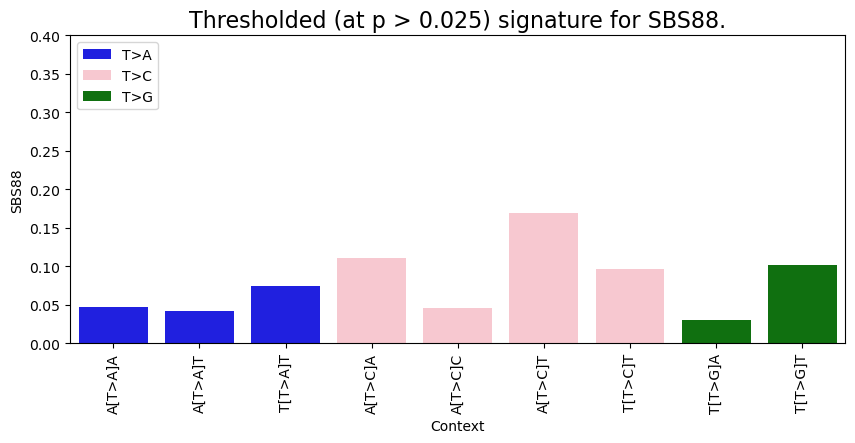

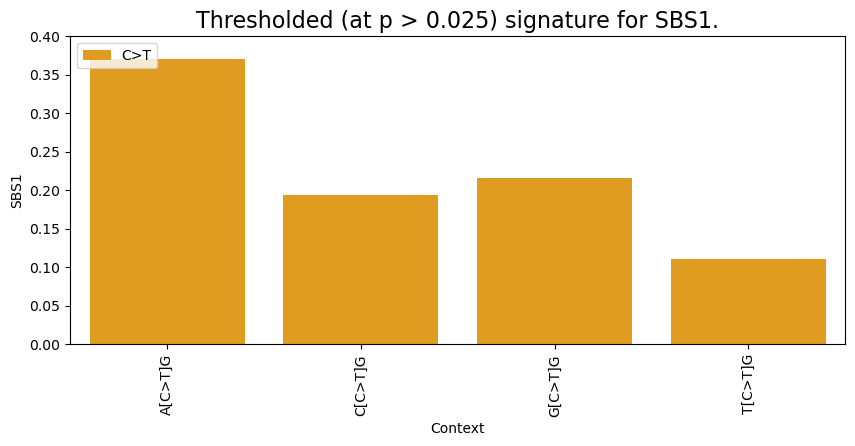

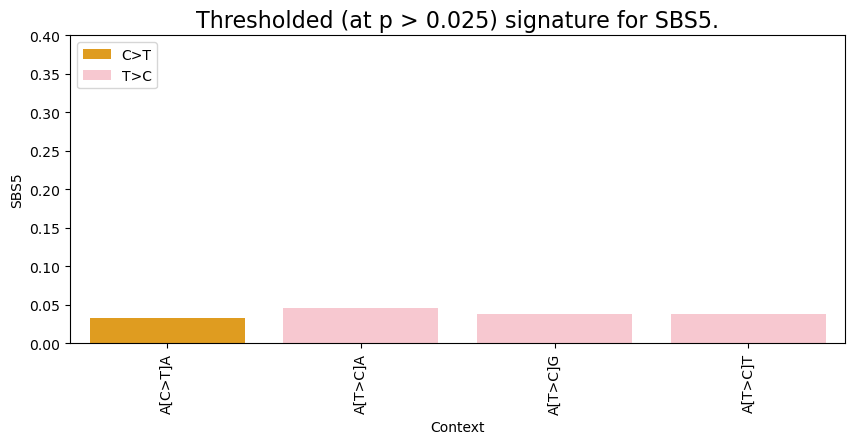

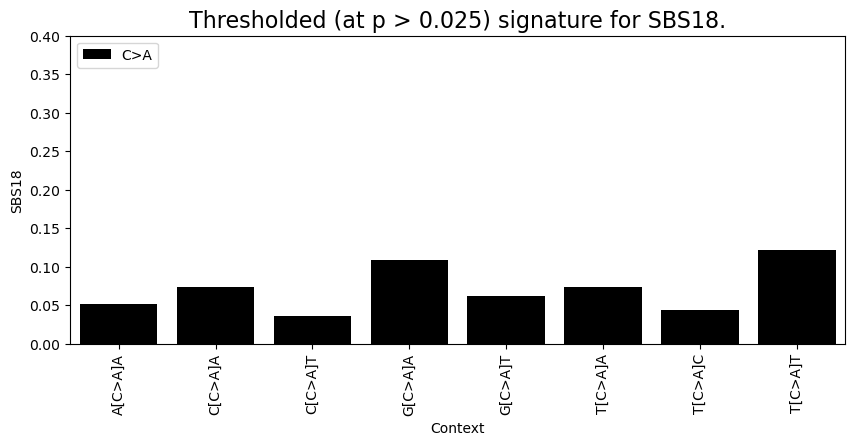

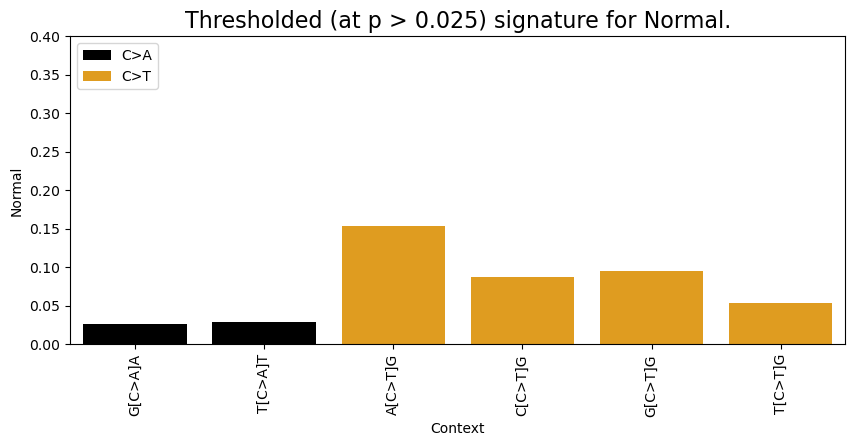

In [92]:
# Keep colours consistent across plots
# Only 6 possible changes so just hard coded it.
sbs_palette = {
    "T>A": "blue",
    "T>C": "red",
    "T>G": "green",
    "C>T": "orange",
    "T>C": "pink",
    "C>A": "black"
}

sig_cols = [col for col in clean_sig_df.columns if ('SBS' in col) or ("Normal" in col)]
for sig_col in sig_cols:
    # Extract, threshold, plot.
    sbs_i = clean_sig_df[["Context", sig_col, "Mutation"]]
    sbs_i_thr = threshold(sbs_i)

    fig, ax = plt.subplots(figsize = (10, 4))
    sns.barplot(data = sbs_i_thr, x = "Context", y = sig_col, 
                hue = "Mutation", palette = sbs_palette)
    ax.tick_params(axis = "x", rotation = 90)
    ax.set_ylim(0, 0.4)

    plt.title(f'Thresholded (at p > 0.025) signature for {sig_col}.', fontsize = 16)
    plt.legend(loc = "upper left")
    plt.show()